## Virtual Moving Test 2 (V2V) Plotting Post-Analysis Correction

In [1]:
import os, re
import json
import numpy as np

import matplotlib.pyplot as plt
import matplotlib.dates as mdates
from matplotlib.ticker import FormatStrFormatter

from datetime import datetime
import math
import pandas as pd
from itertools import chain

from utils import post_process_get_moving_test_data_and_timestamp
from utils import remove_outlier_by_quantile
from static_data_processing import get_test_files_and_survey
from plot_utils import *
from stats_utils import *

from pandas.core.common import SettingWithCopyWarning
import warnings
warnings.filterwarnings("ignore", category=RuntimeWarning) 
warnings.simplefilter(action='ignore', category=SettingWithCopyWarning)

from collections import defaultdict

ROOT_DIR = os.path.join("C:/Users/wangz/OneDrive/University_RU/NSUWB/")
CALIBRATED_CAM_TO_V2B = -6400.8
pd.set_option('display.float_format', lambda x: '%.5f' % x)
pd.set_option('display.max_columns', None)

RESAMPLE_RULE = "1S"
PLOTTING_DPI = 75
static_main_master = 'D91E'
static_focusing_slaves = ['1912', '8D38']
static_master_slave_mapping = { 'D91E': [static_focusing_slaves[0], static_focusing_slaves[1]],
                                '0090': [static_focusing_slaves[1], static_focusing_slaves[0]]}
moving_main_master = '88BA'
moving_focusing_slaves = ['DB00', '069B']
moving_master_slave_mapping = { '88BA': [moving_focusing_slaves[0], moving_focusing_slaves[1]],
                                '111C': [moving_focusing_slaves[1], moving_focusing_slaves[0]]}
STATIC_VEH, MOVING_VEH = 3, 2
VEH_NAME_MAP = {3: "static", 2: "moving"}
test_preset_map = defaultdict(dict)
test_preset_map['PLOTTING_DPI'] = PLOTTING_DPI
test_preset_map['STATIC_VEH'] = STATIC_VEH
test_preset_map['MOVING_VEH'] = MOVING_VEH
test_preset_map[STATIC_VEH]['master_slave_mapping'] = static_master_slave_mapping
test_preset_map[MOVING_VEH]['master_slave_mapping'] = moving_master_slave_mapping
test_preset_map[STATIC_VEH]['main_master'] = static_main_master
test_preset_map[MOVING_VEH]['main_master'] = moving_main_master
test_preset_map['dist_interval_size'] = 1000
#############################################
# if skip plotting any tests, list them here
skiptests = []
#############################################
all_test_files, ground_truth_list = post_process_get_moving_test_data_and_timestamp(ROOT_DIR, 
                                                                                    "Moving Test 2 (Virtual Vehicle)", 
                                                                                    "V2", 
                                                                                    CALIBRATED_CAM_TO_V2B,
                                                                                    skiptests=skiptests)
assert(len(all_test_files) == len(ground_truth_list))
all_test_names_dup = [os.path.basename(os.path.dirname(f)) for f in all_test_files]
# Remove Duplicates of Test Names
all_test_names = []
_ = [all_test_names.append(x) for x in all_test_names_dup if x not in all_test_names]
test_raw_name_file_map = {}
for i in range(len(all_test_names)):
    test_raw_name_file_map[all_test_names[i]] = {}
    a_side_file, b_side_file = all_test_files[2*i], all_test_files[2*i+1]
    test_raw_name_file_map[all_test_names[i]]["A"] = a_side_file
    test_raw_name_file_map[all_test_names[i]]["B"] = b_side_file
    test_raw_name_file_map[all_test_names[i]]["ground_truth"] = ground_truth_list[2*i]
virtual_moving_tests = {}

In [2]:
virtual_moving_tests = {}
for test in all_test_names:
    virtual_moving_tests[test] = parse_single_test_data(test_raw_name_file_map[test]["B"],
                                                        "Virtual Moving Test",
                                                        test_preset_map,
                                                        test_raw_name_file_map[test]["ground_truth"])

processing: 2021-05-25-13-00-19-v2-1-west
processing: 2021-05-25-13-01-56-v2-1-east
2021-05-25-13-01-56-v2-1-east No Data
processing: 2021-05-25-13-07-12-v2-2-west-10mph
processing: 2021-05-25-13-09-08-v2-2-east-15mph
2021-05-25-13-09-08-v2-2-east-15mph No Data
processing: 2021-05-25-13-10-51-v2-3-west-10mph
2021-05-25-13-10-51-v2-3-west-10mph No Data
processing: 2021-05-25-13-12-45-v2-3-east-10mph
2021-05-25-13-12-45-v2-3-east-10mph No Data
processing: 2021-05-25-13-14-27-v2-4-west-20mph
processing: 2021-05-25-13-16-54-v2-4-east-20mph
2021-05-25-13-16-54-v2-4-east-20mph No Data
processing: 2021-05-25-13-24-09-v2-5-west-10mph
processing: 2021-05-25-13-27-19-v2-5-east-15mph
2021-05-25-13-27-19-v2-5-east-15mph No Data
processing: 2021-05-25-13-30-54-v2-6-west-15mph
2021-05-25-13-30-54-v2-6-west-15mph No Data
processing: 2021-05-25-13-33-14-v2-6-east-25mph
2021-05-25-13-33-14-v2-6-east-25mph No Data
processing: 2021-05-25-13-39-32-v2-7-west-edgepush
processing: 2021-05-25-13-42-27-v2-edge

In [3]:
# Global Statistics
static_stats_list_pairwise = []
static_stats_list_aggregated = []
moving_stats_list_pairwise = []
moving_stats_list_aggregated = []

# Combination of All, Indexed by Time
list_df_time_idx_static = []
list_df_time_idx_moving = []

# Combination of All, Indexed by Ground Truth Distances
list_df_dist_idx_static = []
list_df_dist_idx_moving = []

# Combination of All, Indexed by Instance Speed by Markers
list_df_spd_idx_static = []
list_df_spd_idx_moving = []

for raw_name in all_test_names:
    parsing_results = virtual_moving_tests.get(raw_name)
    if not parsing_results:
        continue
    # Unpack dataframes
    df_outlier_overall = parsing_results["df_outlier_overall"]
    moving_ground_truth_df = parsing_results["moving_ground_truth_df"]
    for veh in parsing_results["vehicles"]:
        df_veh_time_idx = parsing_results[veh]["df_veh_time_idx"]
        df_veh_dist_idx = parsing_results[veh]["df_veh_dist_idx"]
        df_veh_spd_idx = parsing_results[veh]["df_veh_spd_idx"]
        veh_err_bins = parsing_results[veh]["veh_err_bins"]
        df_stats_pairwise = parsing_results[veh]['df_stats_pairwise']
        df_stats_aggregated = parsing_results[veh]['df_stats_aggregated']
        if veh == STATIC_VEH:
            df_static_time_idx, static_bins = df_veh_time_idx, veh_err_bins
            list_df_time_idx_static.append(df_veh_time_idx)
            list_df_dist_idx_static.append(df_veh_dist_idx)
            list_df_spd_idx_static.append(df_veh_spd_idx)
            static_stats_list_pairwise.append(df_stats_pairwise)
            static_stats_list_aggregated.append(df_stats_aggregated)
        elif veh == MOVING_VEH:
            df_moving_time_idx, moving_bins = df_veh_time_idx, veh_err_bins
            list_df_time_idx_moving.append(df_veh_time_idx)
            list_df_dist_idx_moving.append(df_veh_dist_idx)
            list_df_spd_idx_moving.append(df_veh_spd_idx)
            moving_stats_list_pairwise.append(df_stats_pairwise)
            moving_stats_list_aggregated.append(df_stats_aggregated)
    
df_all_static_stats_pairwise = pd.concat(static_stats_list_pairwise, ignore_index=True)
df_all_static_stats_aggregated = pd.concat(static_stats_list_aggregated, ignore_index=True)
df_all_static_stats_aggregated["Main Pair Counts"] = np.array(
    df_all_static_stats_pairwise[(df_all_static_stats_pairwise["Is Main Master"]==True) & 
                                             (df_all_static_stats_pairwise["Is Main Slave"]==True)
                                            ]["Reporting Counts"])
df_all_moving_stats_pairwise = pd.concat(moving_stats_list_pairwise, ignore_index=True)
df_all_moving_stats_aggregated = pd.concat(moving_stats_list_aggregated, ignore_index=True)
df_all_moving_stats_aggregated["Main Pair Counts"] = np.array(
    df_all_moving_stats_pairwise[(df_all_moving_stats_pairwise["Is Main Master"]==True) & 
                                             (df_all_moving_stats_pairwise["Is Main Slave"]==True)
                                            ]["Reporting Counts"])

df_all_static_stats_dist_idx = pd.concat(list_df_dist_idx_static)
df_all_static_stats_time_idx = pd.concat(list_df_time_idx_static)
df_all_static_stats_spd_idx = pd.concat(list_df_spd_idx_static)
df_all_moving_stats_dist_idx = pd.concat(list_df_dist_idx_moving)
df_all_moving_stats_time_idx = pd.concat(list_df_time_idx_moving)
df_all_moving_stats_spd_idx = pd.concat(list_df_spd_idx_moving)


In [4]:
for veh_df in [df_all_static_stats_dist_idx, df_all_moving_stats_dist_idx]:
    veh,= veh_df['Initiating Vehicle'].unique()
    print(veh)
    for master in veh_df['Initiating Master'].unique():
        print(master)
        for slave in veh_df['Reporting Slave'].unique():
            print(master, slave)
            veh_df = veh_df[(veh_df['Initiating Master'] == master) & (veh_df['Reporting Slave'] == slave)]

3
D91E
D91E 1912
D91E 8D38
0090
2
88BA
88BA 069B
88BA DB00


In [5]:
def plot_time_series_data_virtual_correction(raw_name, test_dataset, test_category, test_preset_map, pair_selection=None):
    parsing_results = test_dataset.get(raw_name)
    if not parsing_results:
        print(raw_name + " No Data, Not Plotting")
        return
    static_veh, moving_veh = test_preset_map['STATIC_VEH'], test_preset_map['MOVING_VEH']
    
    ################### Unpack dataframes #####################
    df_outlier_overall = parsing_results["df_outlier_overall"]
    moving_ground_truth_df = parsing_results["moving_ground_truth_df"]
    for veh in parsing_results["vehicles"]:
        df_veh_time_idx = parsing_results[veh]["df_veh_time_idx"]
        df_veh_dist_idx = parsing_results[veh]["df_veh_dist_idx"]
        veh_err_bins = parsing_results[veh]["veh_err_bins"]
        df_stats_pairwise = parsing_results[veh]['df_stats_pairwise']
        df_stats_aggregated = parsing_results[veh]['df_stats_aggregated']
        veh_dist_bins = parsing_results[veh]["veh_dist_bins"]
        hist_disp_range = parsing_results[veh]["hist_disp_range"]
        if veh == static_veh:
            df_static_time_idx, static_dist_bins, static_error_bins = df_veh_time_idx, veh_dist_bins, veh_err_bins
            static_hist_disp_range = hist_disp_range
            df_static_dist_idx = df_veh_dist_idx
        elif veh == moving_veh:
            df_moving_time_idx, moving_dist_bins, moving_error_bins = df_veh_time_idx, veh_dist_bins, veh_err_bins
            moving_hist_disp_range = hist_disp_range
            df_moving_dist_idx = df_veh_dist_idx
    list_df_static_time_idx_selected, list_df_moving_time_idx_selected = \
        [pd.DataFrame(columns=df_static_time_idx.columns)], [pd.DataFrame(columns=df_moving_time_idx.columns)]
    for veh in pair_selection.keys():
        if veh == STATIC_VEH:
            for master_id in pair_selection[veh]:
                for slave_id in pair_selection[veh][master_id]:
                    list_df_static_time_idx_selected.append(df_static_time_idx[ (df_static_time_idx['Initiating Master'] == master_id) &
                                                                                (df_static_time_idx['Reporting Slave'] == slave_id)])
        if veh == MOVING_VEH:
            for master_id in pair_selection[veh]:
                for slave_id in pair_selection[veh][master_id]:
                    list_df_moving_time_idx_selected.append(df_moving_time_idx[ (df_moving_time_idx['Initiating Master'] == master_id) &
                                                                                (df_moving_time_idx['Reporting Slave'] == slave_id)])
    ################### Plotting #####################
    figure = plt.figure(figsize=(16, 9), dpi=test_preset_map['PLOTTING_DPI'])
    plot_time_series_dist(  figure=figure,
                            arrange_spec=211,
                            static_veh_df=pd.concat(list_df_static_time_idx_selected),
                            moving_veh_df=pd.concat(list_df_moving_time_idx_selected),
                            static_veh=static_veh,
                            moving_veh=moving_veh,
                            df_outlier=df_outlier_overall.drop(df_outlier_overall.index),
                            surveyed_static_ground_truth_value=None,
                            moving_ground_truth_df=moving_ground_truth_df,
                            scatter=True)
    plot_real_time_moving_errors(   figure=figure, 
                                    arrange_spec=212, 
                                    static_veh_df=pd.concat(list_df_static_time_idx_selected), 
                                    moving_veh_df=pd.concat(list_df_moving_time_idx_selected),
                                    static_veh=static_veh,
                                    moving_veh=moving_veh,
                                    moving_ground_truth_df=moving_ground_truth_df,
                                    scatter=True)
    return pd.concat(list_df_static_time_idx_selected), pd.concat(list_df_moving_time_idx_selected)


In [6]:
def plot_dist_idx_data_virtual_correction(raw_name, test_dataset, test_category, test_preset_map, pair_selection=None):
    parsing_results = test_dataset.get(raw_name)
    if not parsing_results:
        print(raw_name + " No Data, Not Plotting")
        return
    static_veh, moving_veh = test_preset_map['STATIC_VEH'], test_preset_map['MOVING_VEH']
    
    ################### Unpack dataframes #####################
    df_outlier_overall = parsing_results["df_outlier_overall"]
    moving_ground_truth_df = parsing_results["moving_ground_truth_df"]
    for veh in parsing_results["vehicles"]:
        df_veh_time_idx = parsing_results[veh]["df_veh_time_idx"]
        df_veh_dist_idx = parsing_results[veh]["df_veh_dist_idx"]
        veh_err_bins = parsing_results[veh]["veh_err_bins"]
        df_stats_pairwise = parsing_results[veh]['df_stats_pairwise']
        df_stats_aggregated = parsing_results[veh]['df_stats_aggregated']
        veh_dist_bins = parsing_results[veh]["veh_dist_bins"]
        hist_disp_range = parsing_results[veh]["hist_disp_range"]
        if veh == static_veh:
            df_static_time_idx, static_dist_bins, static_error_bins = df_veh_time_idx, veh_dist_bins, veh_err_bins
            static_hist_disp_range = hist_disp_range
            df_static_dist_idx = df_veh_dist_idx
        elif veh == moving_veh:
            df_moving_time_idx, moving_dist_bins, moving_error_bins = df_veh_time_idx, veh_dist_bins, veh_err_bins
            moving_hist_disp_range = hist_disp_range
            df_moving_dist_idx = df_veh_dist_idx
    list_df_static_dist_idx_selected, list_df_moving_dist_idx_selected = \
        [pd.DataFrame(columns=df_static_dist_idx.columns)], [pd.DataFrame(columns=df_moving_time_idx.columns)]
    figure2 = plt.figure(figsize=(16, 9), dpi=test_preset_map['PLOTTING_DPI'])
    ax2 = figure2.add_subplot(111)
    i = 0
    for veh in pair_selection.keys():
        if veh == STATIC_VEH:
            for master_id in pair_selection[veh]:
                for slave_id in pair_selection[veh][master_id]:
                    i += 1
                    list_df_static_dist_idx_selected.append(df_static_dist_idx[ (df_static_dist_idx['Initiating Master'] == master_id) &
                                                                                (df_static_dist_idx['Reporting Slave'] == slave_id)])
                    ax2.scatter(list_df_static_dist_idx_selected[-1].index, list_df_static_dist_idx_selected[-1]['Error (mm)'],
                                label="Static Vehicle, Master {} against {}".format(master_id, slave_id),
                                alpha=0.3,
                                color="C{}".format(i),
                                s=MARKER_SIZE)

        # if veh == MOVING_VEH:
        #     for master_id in pair_selection[veh]:
        #         for slave_id in pair_selection[veh][master_id]:
                    # i += 1
        #             list_df_moving_dist_idx_selected.append(df_moving_dist_idx[ (df_moving_dist_idx['Initiating Master'] == master_id) &
        #                                                                         (df_moving_dist_idx['Reporting Slave'] == slave_id)])
        #             ax2.scatter(list_df_moving_dist_idx_selected[-1].index, list_df_moving_dist_idx_selected[-1]['Error (mm)'],
        #                         label="Moving Vehicle, Master {} against {}".format(master_id, slave_id),
        #                         alpha=0.3,
        #                         color="C{}".format(i),
        #                         s=MARKER_SIZE)
    ax2.set_title("Error v.s. Surveyed Distance")
    ax2.set_xlabel("Distance (mm)")
    ax2.set_ylabel("Error (mm)")
    ax2.legend()
    figure2.tight_layout(pad=1.0)
    ################### Plotting #####################
    
    return pd.concat(list_df_static_dist_idx_selected), pd.concat(list_df_moving_dist_idx_selected)

In [7]:
pair_selection = {  3:{'0090': ['1912', '8D38'], 'D91E': ['1912', '8D38']},
                    2:{'88BA': ['DB00', '069B'], '111C': ['DB00', '069B']}}
# pair_selection = {  3:{'0090': [], 'D91E': ['1912']},
#                     2:{'88BA': [], '111C': []}}

processing: 2021-05-25-13-00-19-v2-1-west


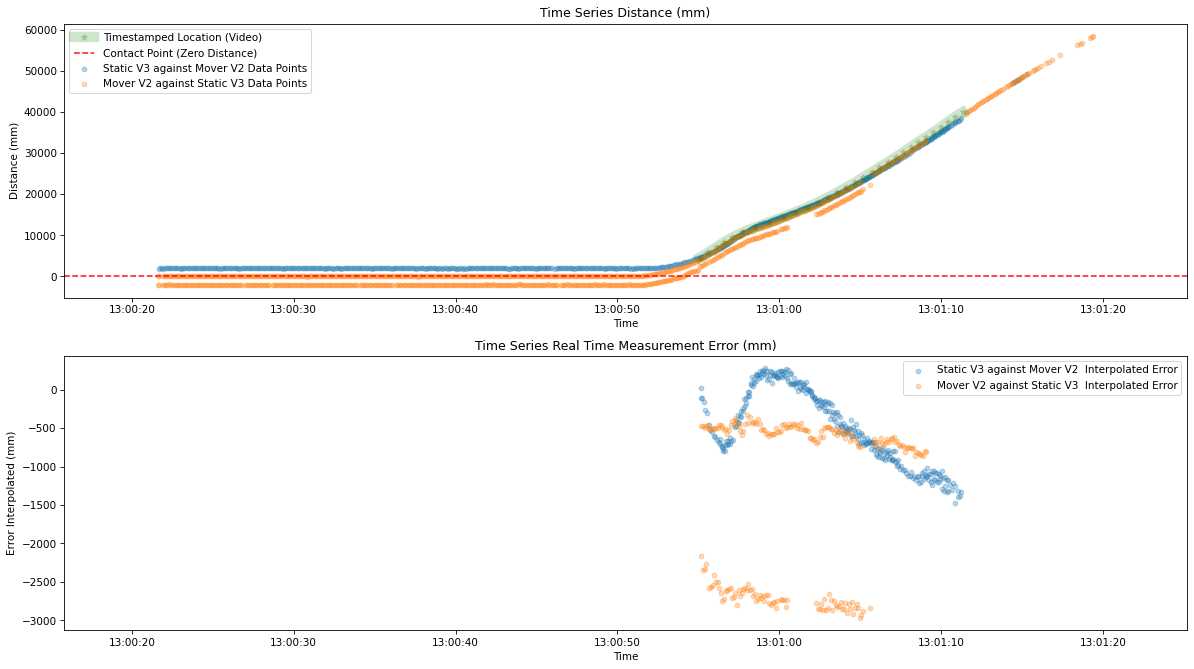

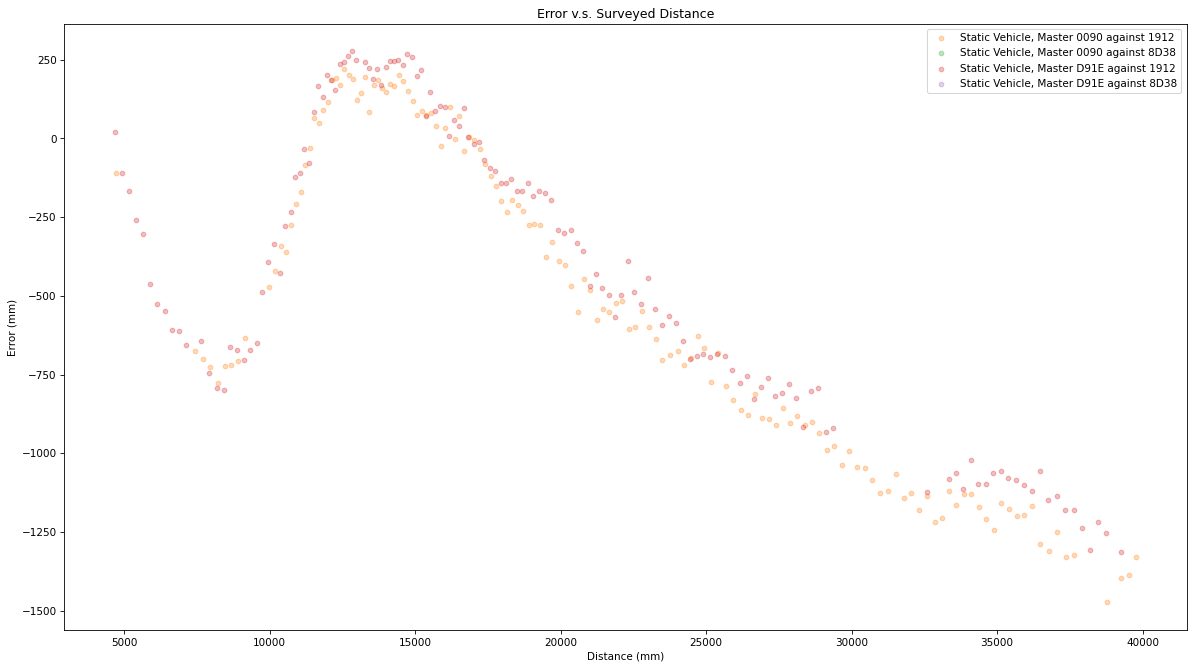

In [8]:
test_1_west = all_test_names[0]
virtual_moving_tests[test_1_west] = parse_single_test_data(test_raw_name_file_map[test_1_west]["B"],"Virtual Moving Test", test_preset_map,
                                                           test_raw_name_file_map[test_1_west]["ground_truth"])
static_time_idx_df, moving_time_idx_df = plot_time_series_data_virtual_correction(test_1_west, virtual_moving_tests, 'Virtual Moving Test', test_preset_map, pair_selection)
static_dist_idx_df, moving_dist_idx_df = plot_dist_idx_data_virtual_correction(test_1_west, virtual_moving_tests, 'Virtual Moving Test', test_preset_map, pair_selection)

processing: 2021-05-25-13-07-12-v2-2-west-10mph


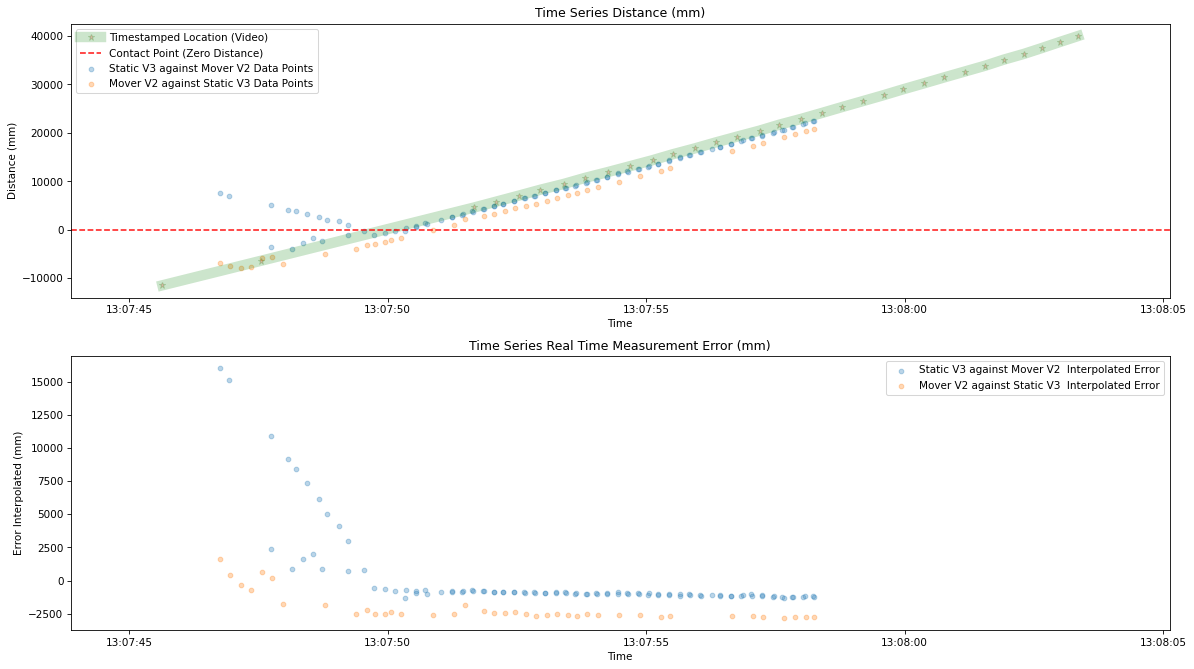

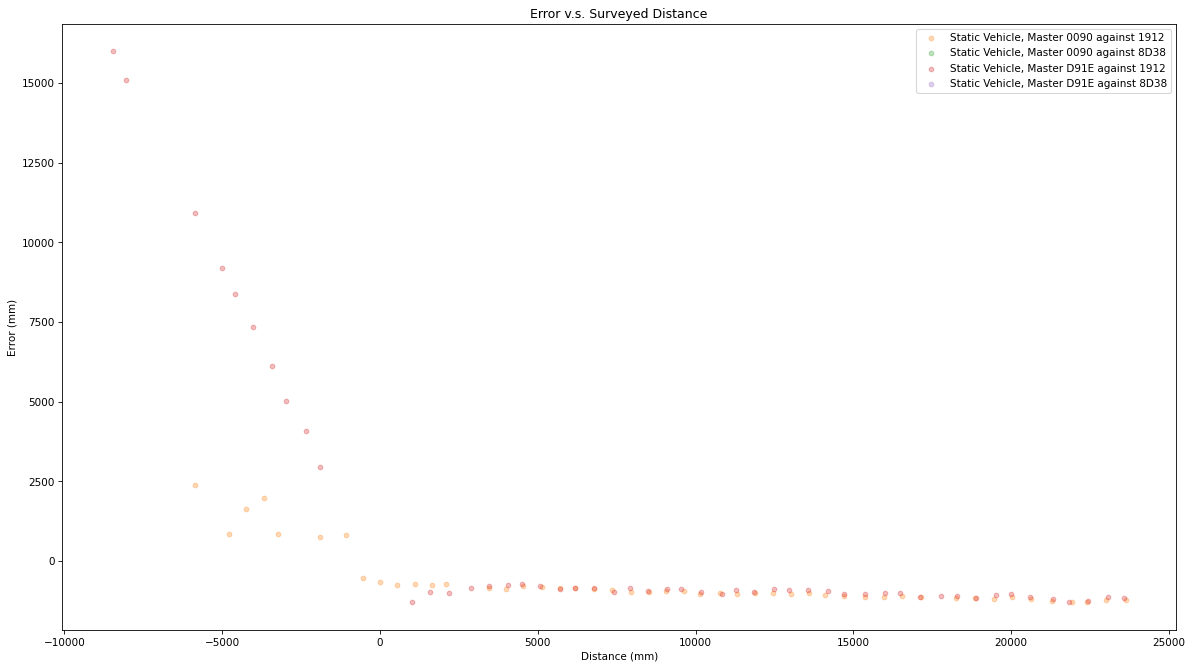

In [9]:
test_2_west = all_test_names[2]
virtual_moving_tests[test_2_west] = parse_single_test_data(test_raw_name_file_map[test_2_west]["B"],"Virtual Moving Test", test_preset_map,
                                                           test_raw_name_file_map[test_2_west]["ground_truth"])
static_time_idx_df, moving_time_idx_df = plot_time_series_data_virtual_correction(test_2_west, virtual_moving_tests, 'Virtual Moving Test', test_preset_map, pair_selection)
static_dist_idx_df, moving_dist_idx_df = plot_dist_idx_data_virtual_correction(test_2_west, virtual_moving_tests, 'Virtual Moving Test', test_preset_map, pair_selection)

processing: 2021-05-25-13-14-27-v2-4-west-20mph


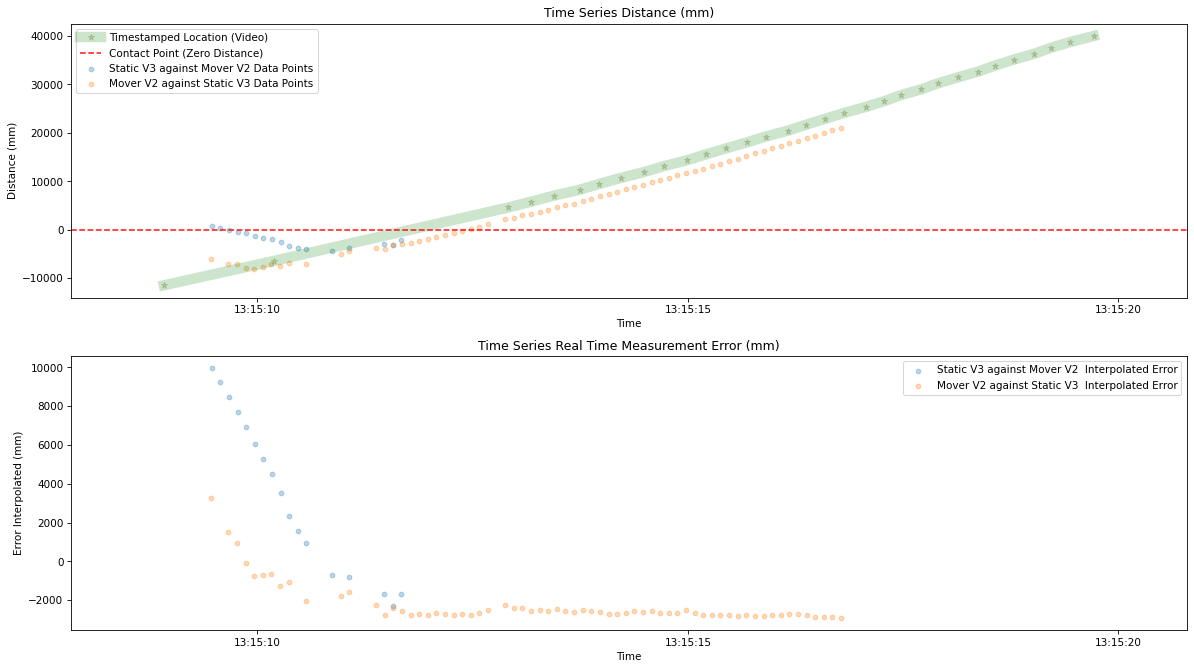

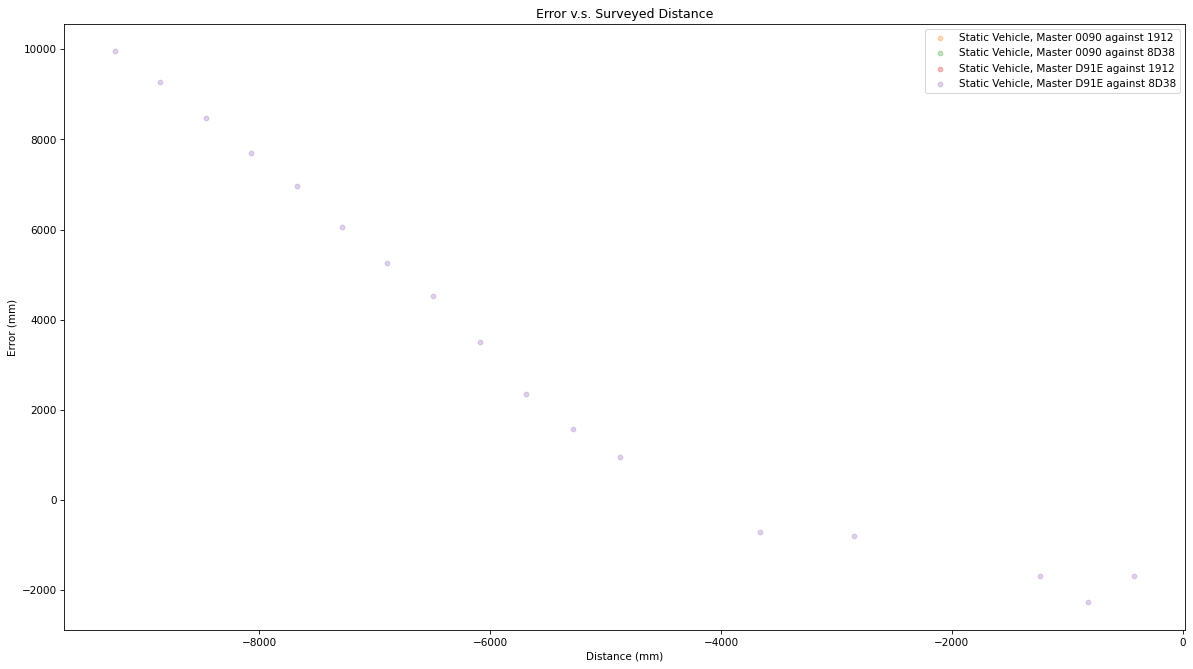

In [10]:
test_4_west = all_test_names[6]
virtual_moving_tests[test_4_west] = parse_single_test_data(test_raw_name_file_map[test_4_west]["B"], "Virtual Moving Test", test_preset_map,
                                                           test_raw_name_file_map[test_4_west]["ground_truth"])
static_time_idx_df, moving_time_idx_df = plot_time_series_data_virtual_correction(test_4_west, virtual_moving_tests, 'Virtual Moving Test', test_preset_map, pair_selection)
static_dist_idx_df, moving_dist_idx_df = plot_dist_idx_data_virtual_correction(test_4_west, virtual_moving_tests, 'Virtual Moving Test', test_preset_map, pair_selection)

processing: 2021-05-25-13-24-09-v2-5-west-10mph


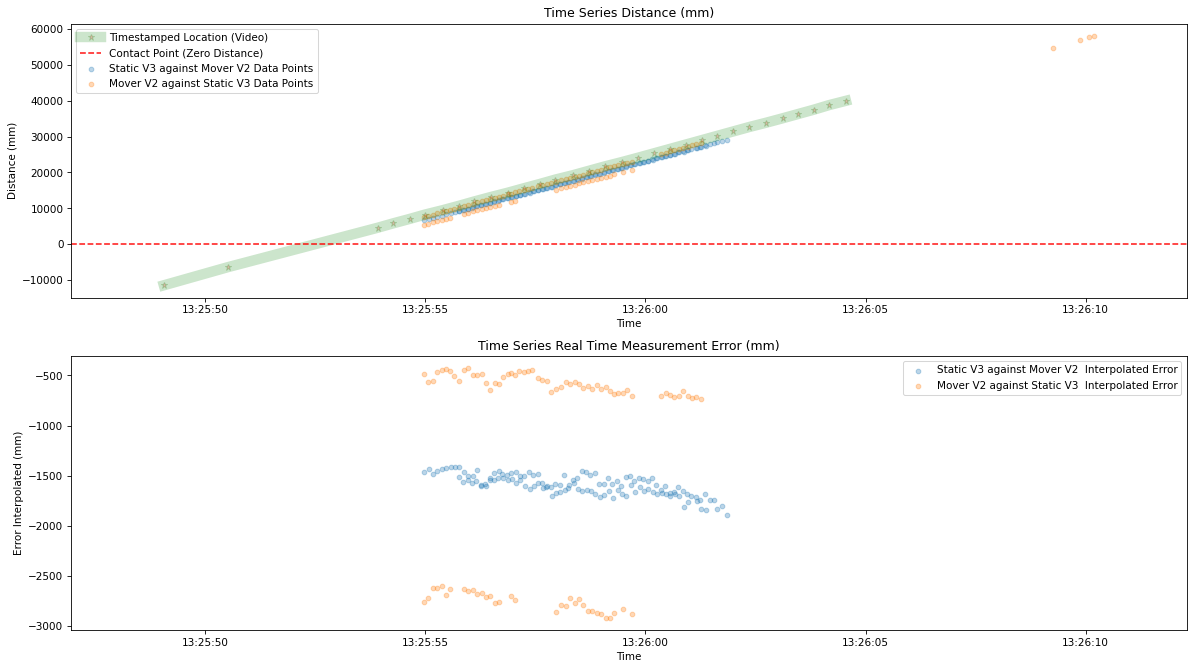

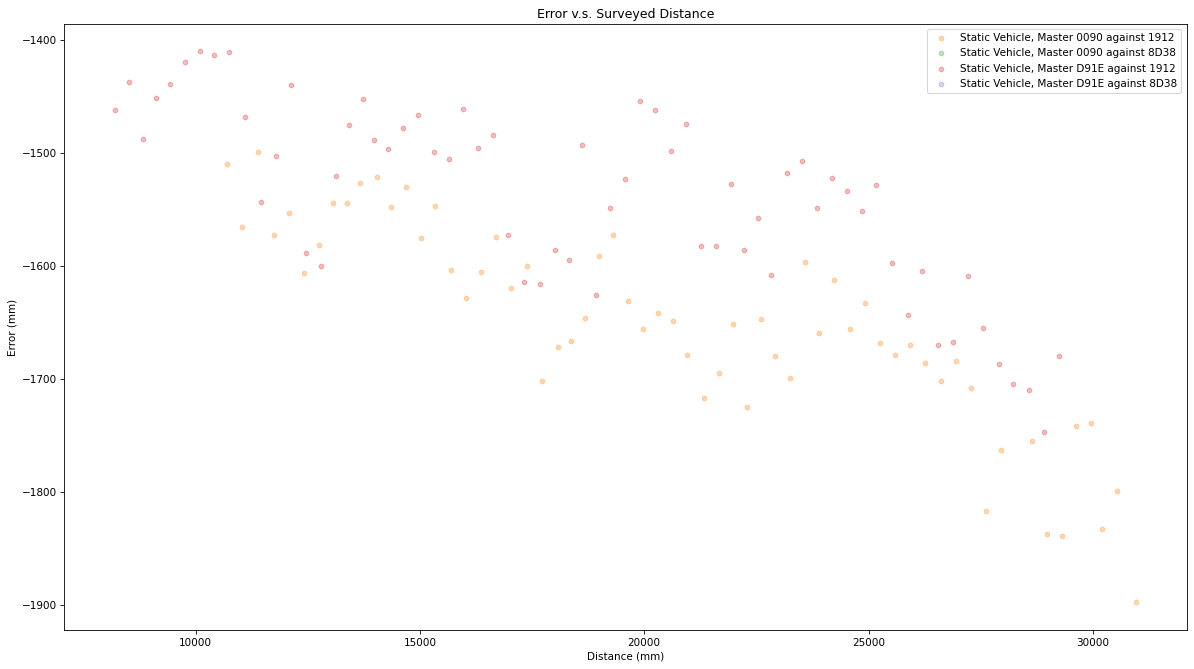

In [11]:
test_5_west = all_test_names[8]
virtual_moving_tests[test_5_west] = parse_single_test_data(test_raw_name_file_map[test_5_west]["B"],"Virtual Moving Test", test_preset_map,
                                                           test_raw_name_file_map[test_5_west]["ground_truth"])
static_time_idx_df, moving_time_idx_df = plot_time_series_data_virtual_correction(test_5_west, virtual_moving_tests, 'Virtual Moving Test', test_preset_map, pair_selection)
static_dist_idx_df, moving_dist_idx_df = plot_dist_idx_data_virtual_correction(test_5_west, virtual_moving_tests, 'Virtual Moving Test', test_preset_map, pair_selection)

processing: 2021-05-25-13-39-32-v2-7-west-edgepush


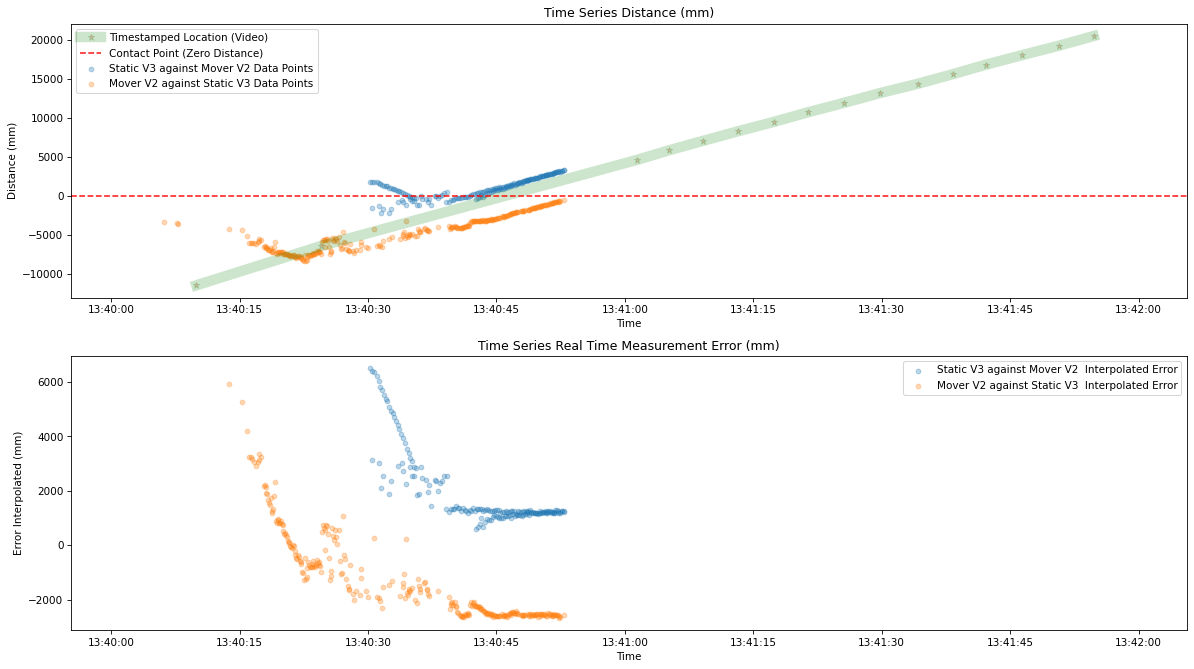

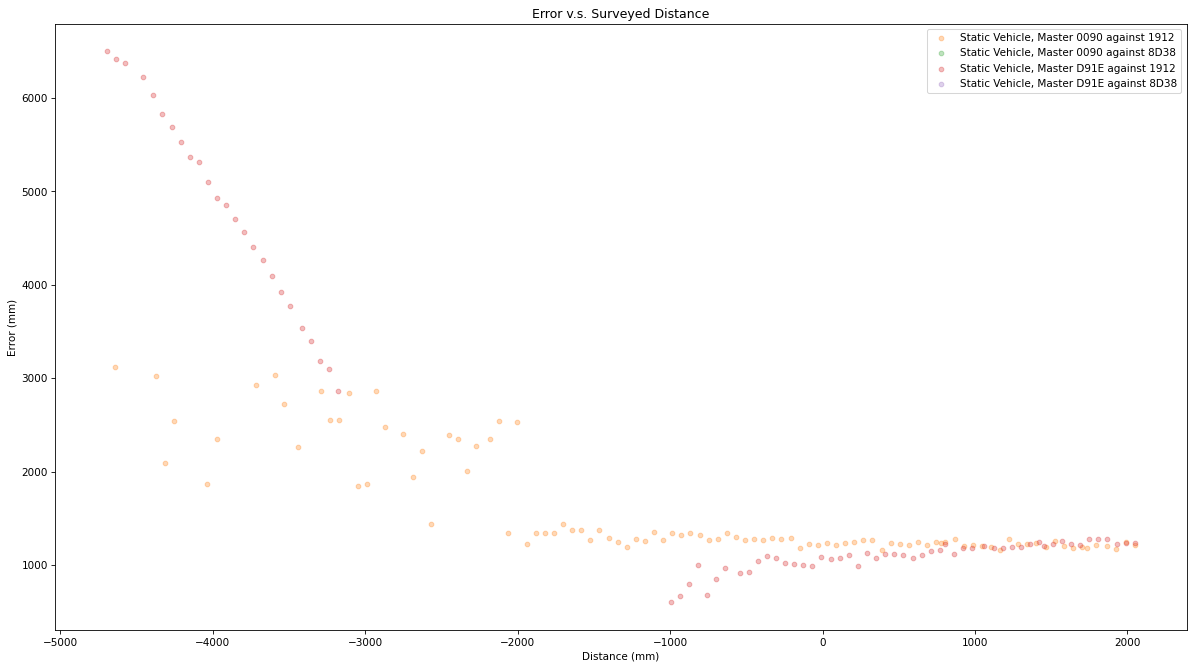

In [12]:
test_7_west_edge_push = all_test_names[12]
virtual_moving_tests[test_7_west_edge_push] = parse_single_test_data(test_raw_name_file_map[test_7_west_edge_push]["B"],"Virtual Moving Test", test_preset_map,
                                                                     test_raw_name_file_map[test_7_west_edge_push]["ground_truth"])
static_time_idx_df, moving_time_idx_df = plot_time_series_data_virtual_correction(test_7_west_edge_push, virtual_moving_tests, 'Virtual Moving Test', test_preset_map, pair_selection)
static_dist_idx_df, moving_dist_idx_df = plot_dist_idx_data_virtual_correction(test_7_west_edge_push, virtual_moving_tests, 'Virtual Moving Test', test_preset_map, pair_selection)

In [13]:
df_all_moving_stats_dist_idx

,Initiating Master,Master Side,Reporting Master X (mm),Reporting Master Y (mm),Reporting Master Z (mm),Initiating Vehicle,Initiating Vehicle Length (mm),Reporting Slave,Slave Side,Reporting Slave X (mm),Reporting Slave Y (mm),Reporting Slave Z (mm),Reporting Vehicle,Reporting Vehicle Length (mm),Correction Distance (mm),UWB Distance (mm),Timestamp Norm (s),Timestamp Local (s),Instant Update Rate (Hz),Test Name,Test Category,Aggregated Update Rate (Hz),UWB Measured Instant Speed - Strict Pair (mph),Aggregated Measured Speed (mph),Instant Speed by Marker (mph),Test Start Time,Error (mm),Reporting Interval (s),Is Main Master,Is Main Slave
Surveyed Distance (mm),,,,,,,,,,,,,,,,,,,,,,,,,,,,,,
NaN,88BA,B,2400.00000,-1470.00000,1890.00000,2,12140,069B,A,0.00000,2108.20000,736.60000,3,7040,-2112.11837,8236,1621947621.59033,1621947622.74667,NaN,2021-05-25-13-00-19-v2-1-west,Virtual Moving Test,NaN,NaN,-1.68033,NaN,2021-05-25 13:00:19,NaN,NaN,True,False
NaN,88BA,B,2400.00000,-1470.00000,1890.00000,2,12140,DB00,B,228.60000,2387.60000,558.80000,3,7040,49.14174,3128,1621947621.59033,1621947622.74667,NaN,2021-05-25-13-00-19-v2-1-west,Virtual Moving Test,NaN,NaN,-0.99726,NaN,2021-05-25 13:00:19,NaN,0.00000,True,True
NaN,88BA,B,2400.00000,-1470.00000,1890.00000,2,12140,069B,A,0.00000,2108.20000,736.60000,3,7040,-2017.83366,8320,1621947621.68921,1621947622.84554,10.00000,2021-05-25-13-00-19-v2-1-west,Virtual Moving Test,NaN,2.13305,-1.68816,NaN,2021-05-25 13:00:19,NaN,0.09888,True,False
NaN,88BA,B,2400.00000,-1470.00000,1890.00000,2,12140,DB00,B,228.60000,2387.60000,558.80000,3,7040,26.92213,3109,1621947621.68921,1621947622.84554,10.00000,2021-05-25-13-00-19-v2-1-west,Virtual Moving Test,NaN,-0.50268,-1.00198,NaN,2021-05-25 13:00:19,NaN,0.00000,True,True
NaN,88BA,B,2400.00000,-1470.00000,1890.00000,2,12140,069B,A,0.00000,2108.20000,736.60000,3,7040,-1981.98034,8352,1621947621.90445,1621947623.06079,4.64582,2021-05-25-13-00-19-v2-1-west,Virtual Moving Test,NaN,0.37260,-1.70225,NaN,2021-05-25 13:00:19,NaN,0.21525,True,False
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
NaN,88BA,B,2400.00000,-1470.00000,1890.00000,2,12140,DB00,B,228.60000,2387.60000,558.80000,3,7040,26095.93336,28770,1621950746.41554,1621950747.57188,10.00000,2021-05-25-13-52-07-v2-9-east,Virtual Moving Test,10.00347,-0.11344,0.05728,NaN,2021-05-25 13:52:07,NaN,0.09875,True,True
NaN,88BA,B,2400.00000,-1470.00000,1890.00000,2,12140,DB00,B,228.60000,2387.60000,558.80000,3,7040,26157.02971,28831,1621950746.51679,1621950747.67313,9.87664,2021-05-25-13-52-07-v2-9-east,Virtual Moving Test,9.99519,1.34983,0.17418,NaN,2021-05-25 13:52:07,NaN,0.10125,True,True
NaN,88BA,B,2400.00000,-1470.00000,1890.00000,2,12140,DB00,B,228.60000,2387.60000,558.80000,3,7040,26100.94127,28775,1621950746.61610,1621950747.77244,10.00000,2021-05-25-13-52-07-v2-9-east,Virtual Moving Test,10.00278,-1.26334,-0.04731,NaN,2021-05-25 13:52:07,NaN,0.09931,True,True
